In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch as torch
from sklearn.datasets import make_moons, make_blobs
import LAMINAR
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

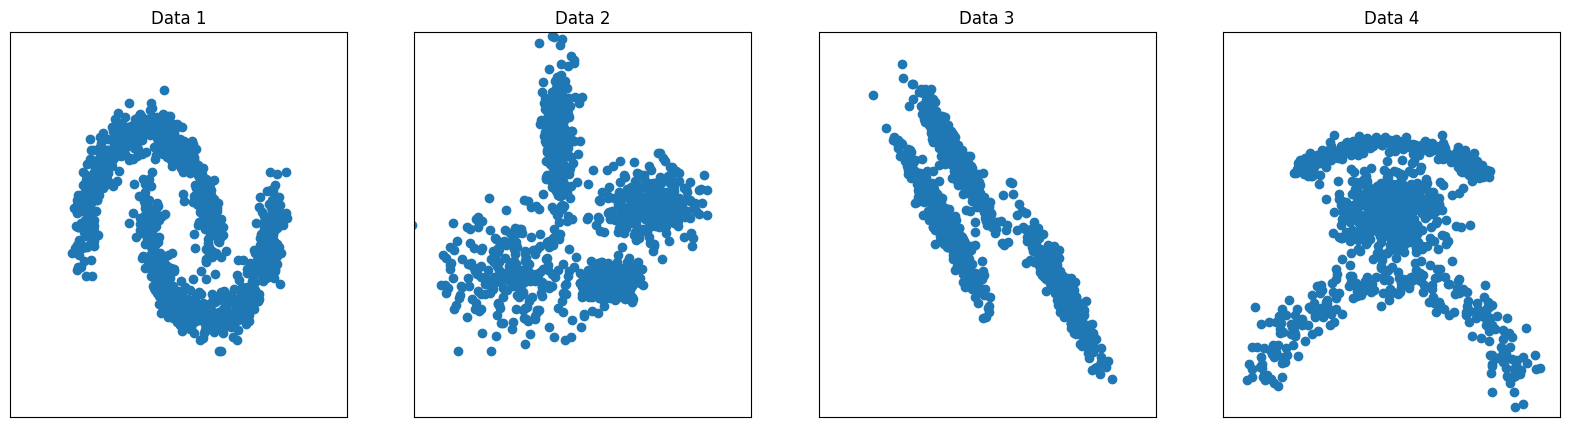

In [4]:
data1 = moons()[0]
data2 = four_gaussians()[0]
data3 = streched_gaussians()[0]
data4 = combined_structure()[0]

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[:, 0], data[:, 1])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlim(-3, 3)
    axs[i].set_ylim(-3, 3)

plt.show()

In [5]:
def LOF(data, test, k=10):
    # LOF algorithm using euclidean distance
    n = test.shape[0]
    dist = torch.cdist(test, data)
    k_dist = torch.topk(dist, k, largest=False).values[:, -1]
    lrd = torch.zeros(n)

    for i in range(n):
        k_neigh = torch.argsort(dist[i])[:k]
        reach_dist = torch.max(k_dist[k_neigh], dist[i, k_neigh])
        lrd[i] = k / torch.sum(reach_dist)

    lof = torch.zeros(n)
    for i in range(n):
        k_neigh = torch.argsort(dist[i])[:k]
        lof[i] = torch.sum(lrd[k_neigh]) / (k * lrd[i])

    return lof


In [6]:
# reference is a grid between -3 and 3 in both dimensions with a total of 50x50 point
def create_reference_grid(n=50):
    x = torch.linspace(-3, 3, n)
    y = torch.linspace(-3, 3, n)
    xx, yy = torch.meshgrid(x, y)
    reference = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    return reference.to(device)

In [7]:
reference = create_reference_grid(n=100)

h:\Uni\Master\Thesis\NFLAM\NFLAM\.venv\Lib\site-packages\torch\functional.py:512: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3588.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [8]:
c1_euc = LOF(data1, reference, k=10)
c2_euc = LOF(data2, reference, k=10)
c3_euc = LOF(data3, reference, k=10)
c4_euc = LOF(data4, reference, k=10)

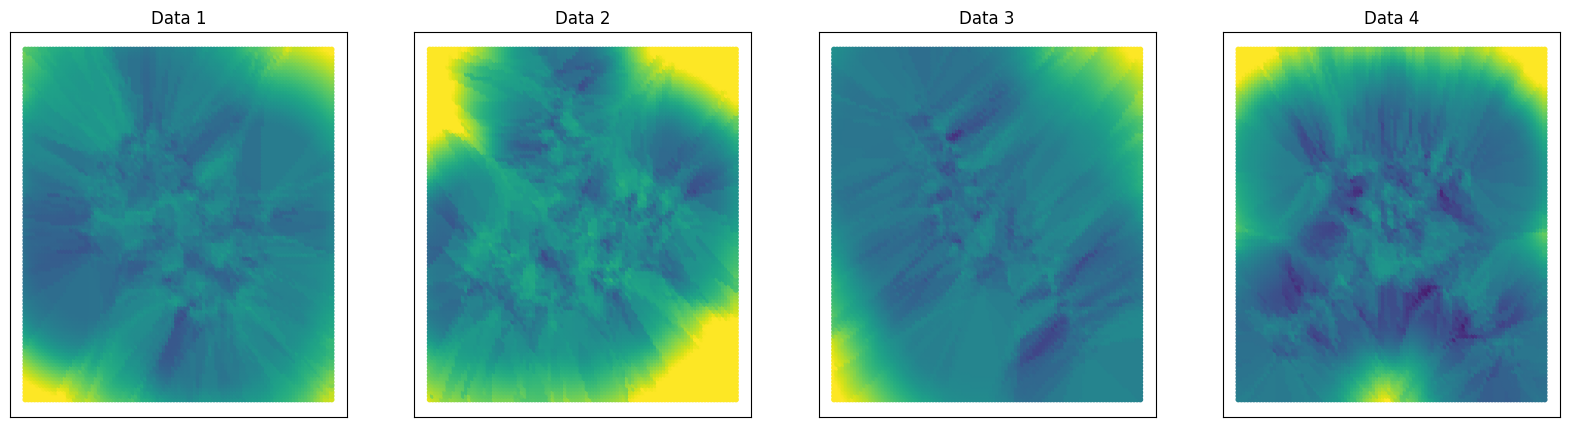

In [9]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data in enumerate([data1, data2, data3, data4]):
    #axs[i].scatter(data[:, 0], data[:, 1])
    axs[i].scatter(reference[:, 0], reference[:, 1], c=eval(f"c{i+1}_euc"), cmap='viridis', s=10, vmin=0.5, vmax=1.5)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [10]:
### LAMINAR

LAM1 = LAMINAR.LAMINAR(data1, drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 2268.655517578125 | Validation Loss: 2268.273193359375
Iteration 99 | Train Loss: 273.353271484375 | Validation Loss: 272.302734375
Iteration 199 | Train Loss: 247.932373046875 | Validation Loss: 246.9798583984375
Iteration 299 | Train Loss: 225.4624481201172 | Validation Loss: 228.31968688964844
Iteration 399 | Train Loss: 218.66769409179688 | Validation Loss: 217.65733337402344
Iteration 499 | Train Loss: 206.9178924560547 | Validation Loss: 210.7925567626953
Iteration 599 | Train Loss: 205.1381378173828 | Validation Loss: 195.06170654296875
Iteration 699 | Train Loss: 189.6858673095703 | Validation Loss: 186.89874267578125
Iteration 799 | Train Loss: 187.9701385498047 | Validation Loss: 183.95997619628906
Iteration 899 | Train Loss: 186.69747924804688 | Validation Loss: 181.8740692138672
Iteration 999 | Train Loss: 186.8375701904297 | Validation Loss: 184.97528076171875
Iteration 1099 | Train Loss: 185.77528381347656 | Validation Loss: 186.1422882080078
Ite

In [11]:
LAM2 = LAMINAR.LAMINAR(data2, drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 2071.4423828125 | Validation Loss: 2073.4033203125
Iteration 99 | Train Loss: 266.7313232421875 | Validation Loss: 276.8947448730469
Iteration 199 | Train Loss: 256.4536437988281 | Validation Loss: 264.94256591796875
Iteration 299 | Train Loss: 196.6021728515625 | Validation Loss: 203.6160888671875
Iteration 399 | Train Loss: 196.31756591796875 | Validation Loss: 203.56333923339844
Iteration 499 | Train Loss: 192.54473876953125 | Validation Loss: 198.05902099609375
Iteration 599 | Train Loss: 193.34454345703125 | Validation Loss: 202.91221618652344
Iteration 699 | Train Loss: 192.91969299316406 | Validation Loss: 200.3069305419922
Iteration 799 | Train Loss: 192.58348083496094 | Validation Loss: 200.5291290283203
Iteration 899 | Train Loss: 190.9544219970703 | Validation Loss: 199.24203491210938
Iteration 999 | Train Loss: 192.4636993408203 | Validation Loss: 197.58546447753906
Iteration 1099 | Train Loss: 189.71365356445312 | Validation Loss: 201.040100097656

In [12]:
LAM3 = LAMINAR.LAMINAR(data3, drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1698.99267578125 | Validation Loss: 1697.7869873046875
Iteration 99 | Train Loss: 177.84869384765625 | Validation Loss: 171.15310668945312
Iteration 199 | Train Loss: 172.233642578125 | Validation Loss: 172.28077697753906
Iteration 299 | Train Loss: 175.39077758789062 | Validation Loss: 175.13543701171875
Iteration 399 | Train Loss: 131.45152282714844 | Validation Loss: 133.5822296142578
Iteration 499 | Train Loss: 125.41849517822266 | Validation Loss: 127.87612915039062
Iteration 599 | Train Loss: 122.29769134521484 | Validation Loss: 124.1694107055664
Iteration 699 | Train Loss: 121.14493560791016 | Validation Loss: 126.5989761352539
Iteration 799 | Train Loss: 124.59970092773438 | Validation Loss: 134.131103515625
Iteration 899 | Train Loss: 119.60643768310547 | Validation Loss: 124.57707977294922
Iteration 999 | Train Loss: 119.89058685302734 | Validation Loss: 127.12105560302734
Iteration 1099 | Train Loss: 119.34886169433594 | Validation Loss: 129.086166

In [13]:
LAM4 = LAMINAR.LAMINAR(data4, drop_freq=9999, epochs=1500)

Iteration 0 | Train Loss: 1930.5703125 | Validation Loss: 1930.6669921875
Iteration 99 | Train Loss: 273.2864074707031 | Validation Loss: 278.1853332519531
Iteration 199 | Train Loss: 225.6190643310547 | Validation Loss: 241.77609252929688
Iteration 299 | Train Loss: 220.29881286621094 | Validation Loss: 235.15054321289062
Iteration 399 | Train Loss: 215.3675079345703 | Validation Loss: 233.10366821289062
Iteration 499 | Train Loss: 197.8505859375 | Validation Loss: 215.40521240234375
Iteration 599 | Train Loss: 192.9179229736328 | Validation Loss: 211.217041015625
Iteration 699 | Train Loss: 190.21885681152344 | Validation Loss: 209.57415771484375
Iteration 799 | Train Loss: 189.8047332763672 | Validation Loss: 211.6634521484375
Iteration 899 | Train Loss: 188.28321838378906 | Validation Loss: 210.9658966064453
Iteration 999 | Train Loss: 187.28494262695312 | Validation Loss: 211.9755401611328
Iteration 1099 | Train Loss: 185.94720458984375 | Validation Loss: 212.31796264648438
Iterat

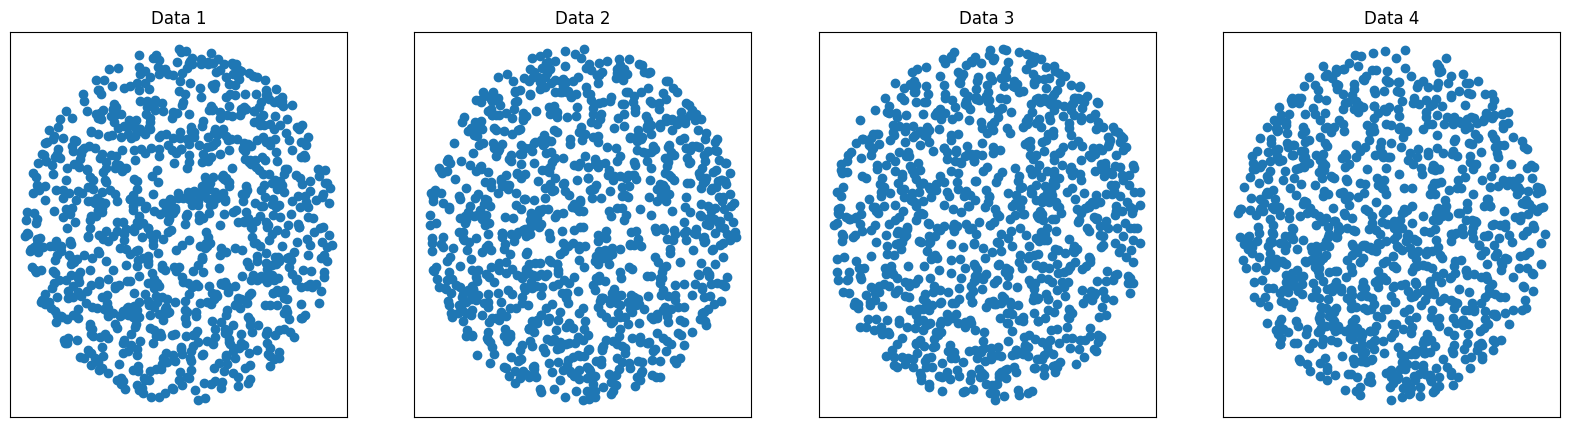

In [14]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed]):
    axs[i].scatter(data_pushed[:, 0], data_pushed[:, 1])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [15]:
idx, dists_matrix, _ = LAM1.check_expansion(reference)

In [16]:
tk = torch.topk(dists_matrix, 10, largest=False)

In [17]:
tk[0].shape

torch.Size([11000, 10])

In [18]:
def LOF_LAM(data, test, LAM, k=10):
    # LOF algorithm using euclidean distance
    n = test.shape[0] + data.shape[0]
    
    idx, dists_matrix, _ = LAM.check_expansion(test)
    k_dist, k_indices = torch.topk(dists_matrix, k, largest=False)

    lrd = torch.zeros(n)

    print(dists_matrix.shape)

    for i in range(n):
        k_neigh = k_indices[i]
        reach_dist = torch.maximum(k_dist[i], k_dist[:, -1][k_neigh])
        lrd[i] = k / torch.sum(reach_dist)

    lof = torch.zeros(n)
    for i in range(n):
        k_neigh = k_indices[i]
        lof[i] = torch.sum(lrd[k_neigh]) / (k * lrd[i])

    return lof[idx]

In [19]:
c1_lam = LOF_LAM(data1, reference, LAM1, k=10)
c2_lam = LOF_LAM(data2, reference, LAM2, k=10)
c3_lam = LOF_LAM(data3, reference, LAM3, k=10)
c4_lam = LOF_LAM(data4, reference, LAM4, k=10)

torch.Size([11000, 11000])
torch.Size([11000, 11000])
torch.Size([11000, 11000])
torch.Size([11000, 11000])


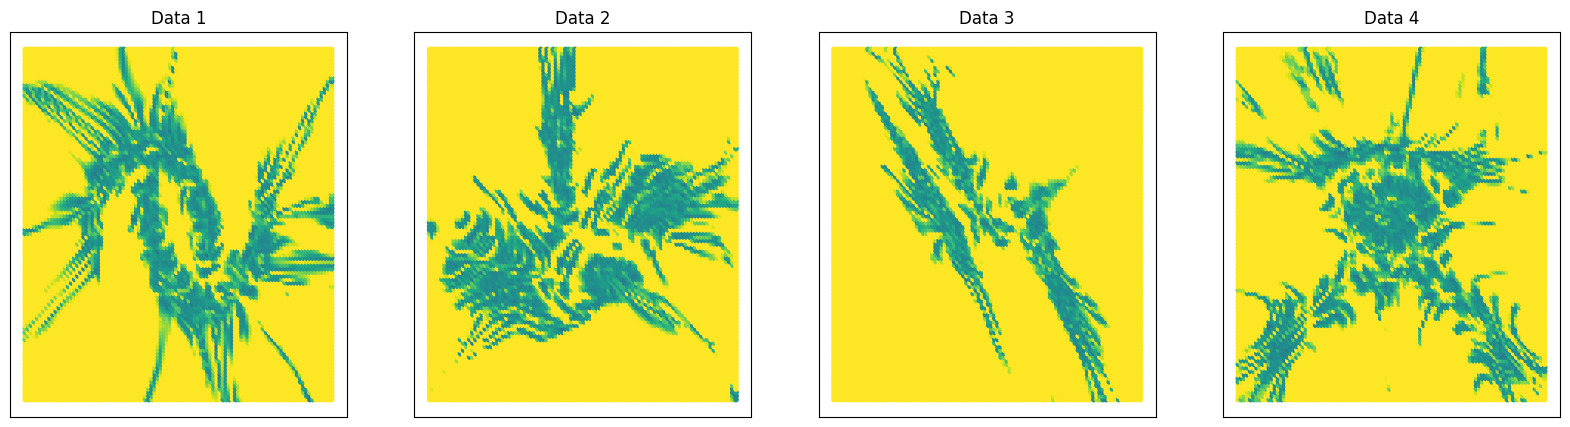

In [20]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data in enumerate([data1, data2, data3, data4]):
    #axs[i].scatter(data[:, 0], data[:, 1])
    axs[i].scatter(reference[:, 0], reference[:, 1], c=eval(f"c{i+1}_lam"), cmap='viridis', s=10, vmin=0.5, vmax=1.5)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [21]:
c1_q = c1_lam/c1_euc
c2_q = c2_lam/c2_euc
c3_q = c3_lam/c3_euc
c4_q = c4_lam/c4_euc

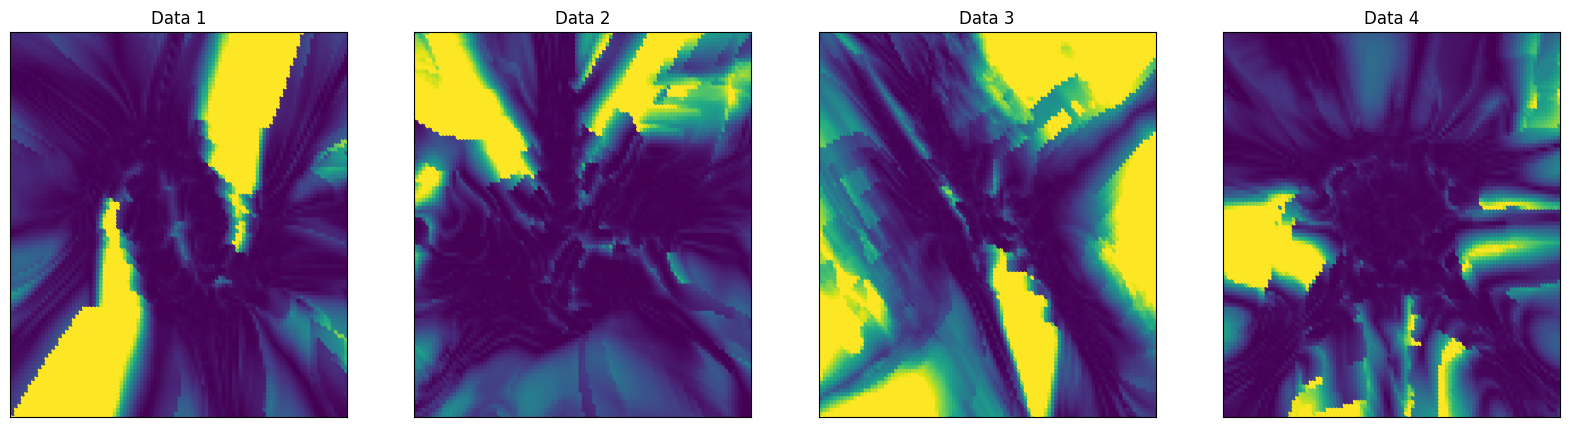

In [22]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data in enumerate([data1, data2, data3, data4]):
    #axs[i].scatter(data[:, 0], data[:, 1])
    axs[i].scatter(reference[:, 0], reference[:, 1], c=eval(f"c{i+1}_q"), cmap='viridis', s=10, vmin=1, vmax=20)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_xlim(-3, 3)
    axs[i].set_ylim(-3, 3)

plt.show()

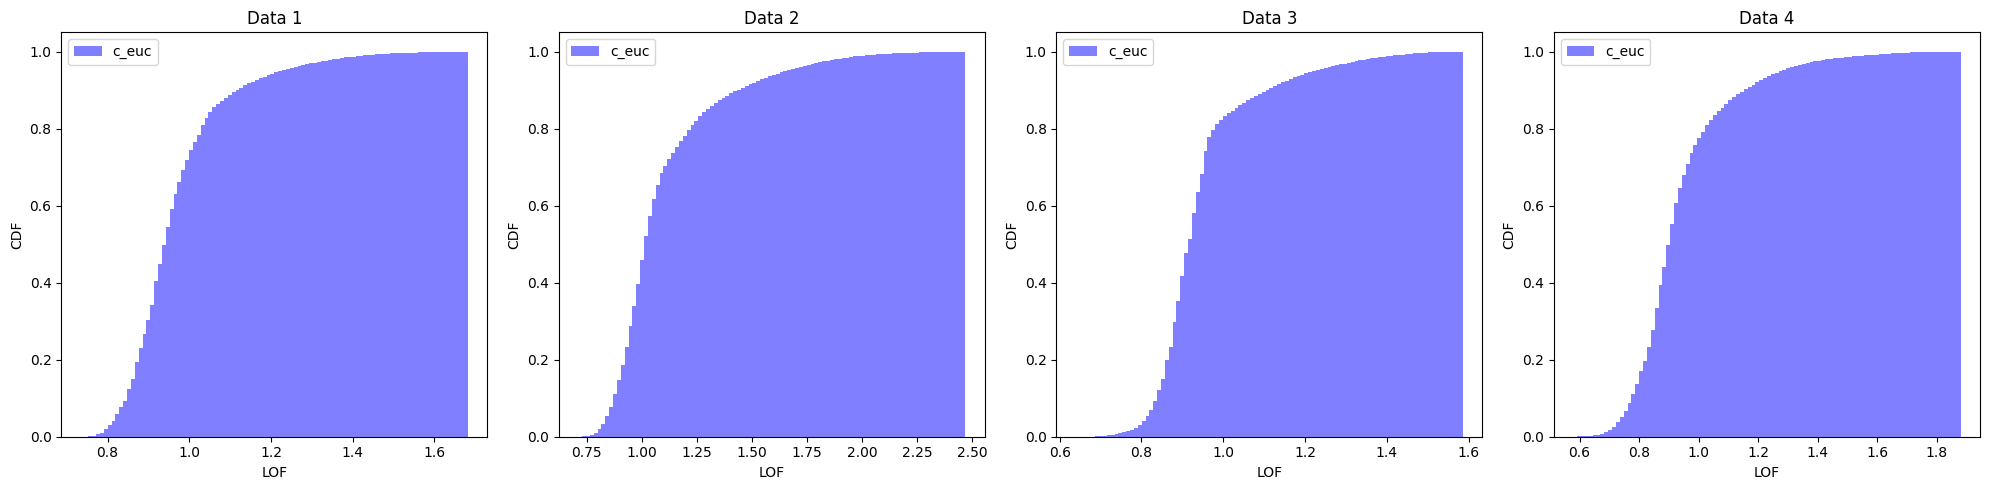

In [ ]:
# plot cdf histograms for each data set  c_euc and c_lam

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].hist(c1_euc.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[0].set_title('Data 1')
axs[0].set_xlabel('LOF')
axs[0].set_ylabel('CDF')
axs[0].legend()

axs[1].hist(c2_euc.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[1].set_title('Data 2')
axs[1].set_xlabel('LOF')
axs[1].set_ylabel('CDF')
axs[1].legend()

axs[2].hist(c3_euc.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[2].set_title('Data 3')
axs[2].set_xlabel('LOF')
axs[2].set_ylabel('CDF')
axs[2].legend()

axs[3].hist(c4_euc.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[3].set_title('Data 4')
axs[3].set_xlabel('LOF')
axs[3].set_ylabel('CDF')
axs[3].legend()

plt.tight_layout()

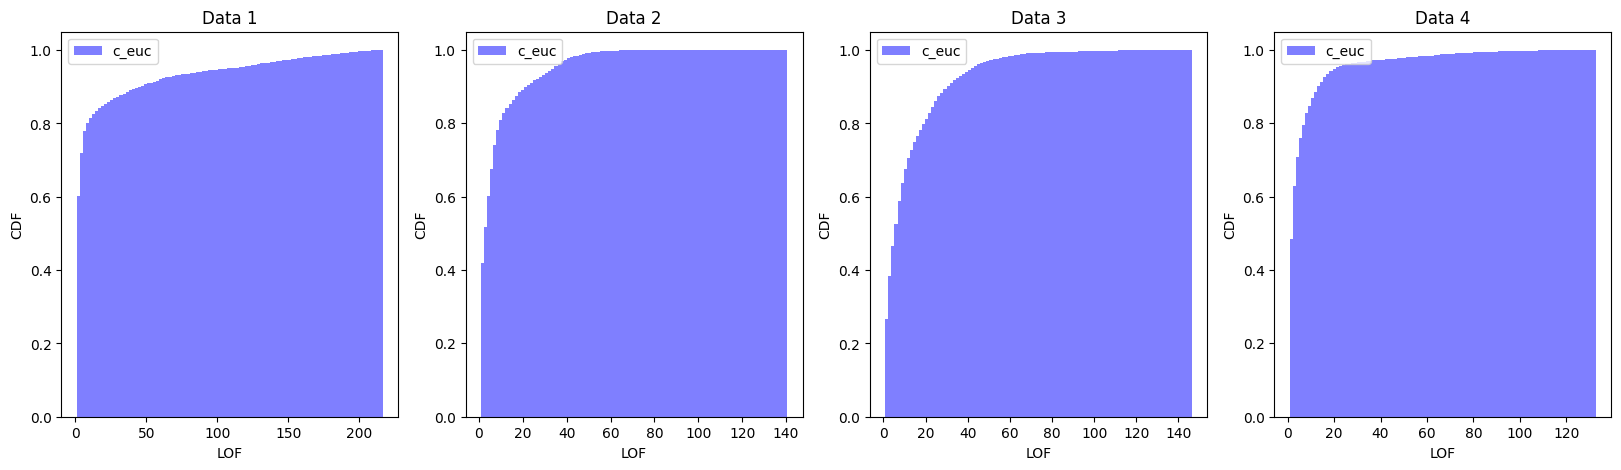

In [25]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].hist(c1_lam.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[0].set_title('Data 1')
axs[0].set_xlabel('LOF')
axs[0].set_ylabel('CDF')
axs[0].legend()

axs[1].hist(c2_lam.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[1].set_title('Data 2')
axs[1].set_xlabel('LOF')
axs[1].set_ylabel('CDF')
axs[1].legend()

axs[2].hist(c3_lam.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[2].set_title('Data 3')
axs[2].set_xlabel('LOF')
axs[2].set_ylabel('CDF')
axs[2].legend()

axs[3].hist(c4_lam.cpu().numpy(), bins=100, density=True, cumulative=True, color='blue', alpha=0.5, label='c_euc')
axs[3].set_title('Data 4')
axs[3].set_xlabel('LOF')
axs[3].set_ylabel('CDF')
axs[3].legend()